# 04 — Random Forest baseline classifier

Here I try to train a baseline random forest to predict whether a cell was treated with a **senescence inducer** vs **DMSO control**, with features Emiliya already extracted. This week is about establishing a working baseline; next weeks we'll try adding new features and other models.

## 0. Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setting Storage root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES  = PROJECT_ROOT / "outputs" / "tables"
MODELS  = PROJECT_ROOT / "outputs" / "models"
for d in (FIGURES, TABLES, MODELS):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "df_clean_wide.csv")
mapping = pd.DataFrame({
    "Metadata_JCP2022": ["JCP2022_033924", "JCP2022_095995", "JCP2022_001418", "JCP2022_094347", "JCP2022_051785"],
    "drug_name":        ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"],
    "category":         ["control", "senescence_inducer", "senescence_inducer", "senescence_inducer", "seno_modulator"],
})
df = df.merge(mapping, on="Metadata_JCP2022", how="left")
df = df[
    (df["Cells_AreaShape_FormFactor"] <= 1)   & (df["Nuclei_AreaShape_FormFactor"] <= 1) &
    (df["Cells_AreaShape_EulerNumber"] == 1)  & (df["Nuclei_AreaShape_EulerNumber"] == 1) &
    (df["NC_Ratio"] <= 1)                     & (df["NC_Ratio_Radius"] <= 1)
].copy()

sns.set_theme(style="whitegrid")
print(f"Filtered cells: {len(df):,}")
print(df["drug_name"].value_counts().to_string())


Filtered cells: 102,430
drug_name
DMSO           86012
hydroxyurea     6586
palbociclib     4708
resveratrol     3891
etoposide       1233


## 1. Define the prediction problem
Training data: cells treated with DMSO (label 0) or any of the three inducers (label 1).

We use the same 16 morphology features as in the PCA notebook, and excluding `ImageNumber`, the `Count_*` columns (image-level metadata), and the `EulerNumber` columns.

In [15]:
FEATURES = [
    "Cells_AreaShape_BoundingBoxArea",  "Cells_AreaShape_Compactness",
    "Cells_AreaShape_Eccentricity",     "Cells_AreaShape_FormFactor",
    "Cells_AreaShape_MeanRadius",       "Cells_AreaShape_Perimeter",
    "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea", "Nuclei_AreaShape_Compactness",
    "Nuclei_AreaShape_Eccentricity",    "Nuclei_AreaShape_FormFactor",
    "Nuclei_AreaShape_MeanRadius",      "Nuclei_AreaShape_Perimeter",
    "Nuclei_AreaShape_Solidity",
    "NC_Ratio",                         "NC_Ratio_Radius",
]

# Training set: DMSO + the 3 inducers
INDUCERS = ["etoposide", "hydroxyurea", "palbociclib"]
df_train = df[df["drug_name"].isin(["DMSO"] + INDUCERS)].copy()

# y = 1 for inducer, 0 for DMSO
df_train["label"] = (df_train["drug_name"].isin(INDUCERS)).astype(int)

# Group ID = well within the project
df_train["well_id"] = df_train["Metadata_Plate"] + "_" + df_train["Metadata_Well"]

# Held-out exploration set: resveratrol
# Resveratrol is the famous "red wine compound" that's been claimed to slow aging. 
# Mechanism in this experiment: it actually depletes DNA building blocks similarly to hydroxyurea, 
# and it extends lifespan in worms/flies/mice. Expectation result is unclear, that's why it's interesting.
# It could behave like a senescence inducer (because it causes replication stress) or like a "good" compound 
# that protects against senescence. Emiliya labels it a "seno-modulator" because the effect depends on dose and context.
df_holdout = df[df["drug_name"] == "resveratrol"].copy()

print(f"Training cells: {len(df_train):,}")
print(df_train["drug_name"].value_counts().to_string())
print(f"\nUnique training wells: {df_train['well_id'].nunique()}")
print(f"Class balance: DMSO={(df_train['label']==0).sum():,}  inducer={(df_train['label']==1).sum():,}")
print(f"\nHeld-out resveratrol cells: {len(df_holdout):,}")


Training cells: 98,539
drug_name
DMSO           86012
hydroxyurea     6586
palbociclib     4708
etoposide       1233

Unique training wells: 47
Class balance: DMSO=86,012  inducer=12,527

Held-out resveratrol cells: 3,891


## 2. Cross-validation setup

5-fold means 80% of wells are used for training and 20% for testing in each fold, repeated 5 times so every well gets to be in the test set exactly once.

In [16]:
from sklearn.model_selection import GroupKFold

X = df_train[FEATURES].values
y = df_train["label"].values
groups = df_train["well_id"].values

n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# Quick sanity check: print the train/test sizes and class balance per fold
print(f"{'Fold':>4} | {'Train n':>9} {'(% pos)':>7} | {'Test n':>9} {'(% pos)':>7} | {'Train wells':>11} {'Test wells':>10}")
print("-" * 78)
for i, (tr, te) in enumerate(gkf.split(X, y, groups)):
    train_pos = y[tr].mean() * 100
    test_pos  = y[te].mean() * 100
    n_tr_wells = len(set(groups[tr]))
    n_te_wells = len(set(groups[te]))
    print(f"{i:>4} | {len(tr):>9} {train_pos:>6.1f}% | {len(te):>9} {test_pos:>6.1f}% | {n_tr_wells:>11} {n_te_wells:>10}")


Fold |   Train n (% pos) |    Test n (% pos) | Train wells Test wells
------------------------------------------------------------------------------
   0 |     78536   13.2% |     20003   10.8% |          38          9
   1 |     79131   14.2% |     19408    6.5% |          38          9
   2 |     78700   11.0% |     19839   19.3% |          37         10
   3 |     78657   10.9% |     19882   20.0% |          37         10
   4 |     79132   14.2% |     19407    6.7% |          38          9


## 3. Train Random Forest with cross-validation

Setting kwargs:
- `n_estimators=200` — number of trees. 
- `class_weight='balanced'` — automatically up-weights the minority class so the model doesn't just learn to predict DMSO all the time.
- `n_jobs=-1` — use all CPU cores in parallel.


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve

fold_results = []
all_y_true = []     
all_y_pred = []
all_y_prob = []
feature_importance_per_fold = []

for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_te = X[tr], X[te]
    y_tr, y_te = y[tr], y[te]

    clf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42 + fold_idx,
        n_jobs=-1,
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]   

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    fold_results.append({"fold": fold_idx, "n_train": len(tr), "n_test": len(te),
                         "test_pct_pos": float(y_te.mean()), "accuracy": acc, "auc": auc})
    all_y_true.append(y_te)
    all_y_pred.append(y_pred)
    all_y_prob.append(y_prob)
    feature_importance_per_fold.append(clf.feature_importances_)
    print(f"Fold {fold_idx}: accuracy={acc:.3f}, AUC={auc:.3f}")

results_df = pd.DataFrame(fold_results)
print("\n----- Cross-validation summary -----")
print(f"Mean accuracy: {results_df['accuracy'].mean():.3f} ± {results_df['accuracy'].std():.3f}")
print(f"Mean AUC:      {results_df['auc'].mean():.3f} ± {results_df['auc'].std():.3f}")
results_df.to_csv(TABLES / "rf_cv_per_fold.csv", index=False)


Fold 0: accuracy=0.880, AUC=0.526
Fold 1: accuracy=0.939, AUC=0.768
Fold 2: accuracy=0.835, AUC=0.695
Fold 3: accuracy=0.836, AUC=0.679
Fold 4: accuracy=0.942, AUC=0.779

----- Cross-validation summary -----
Mean accuracy: 0.887 ± 0.053
Mean AUC:      0.690 ± 0.101


## 4. Confusion matrix and ROC curve

Pool predictions across all 5 folds (every cell is in the test set of exactly one fold). One combined confusion matrix tells us the overall true-positive / false-positive structure; one combined ROC curve summarizes the model's tradeoff between sensitivity and specificity.

Confusion matrix (counts):
                Predicted DMSO  Predicted inducer
Actual DMSO              85253                759
Actual inducer           10473               2054


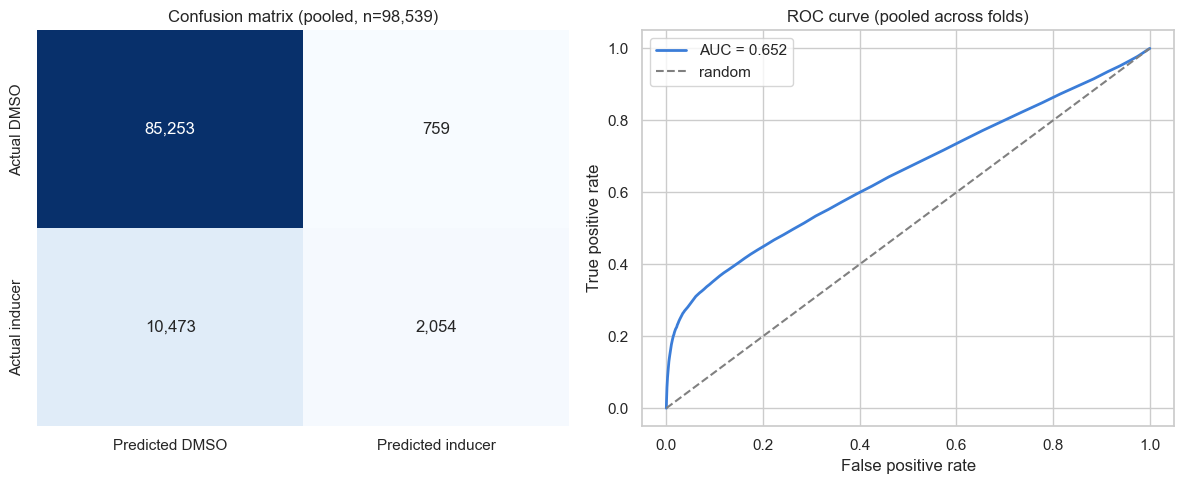

In [8]:
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
y_prob_all = np.concatenate(all_y_prob)

# ---- Confusion matrix ----
cm = confusion_matrix(y_true_all, y_pred_all)
cm_df = pd.DataFrame(cm,
                     index=["Actual DMSO", "Actual inducer"],
                     columns=["Predicted DMSO", "Predicted inducer"])
print("Confusion matrix (counts):")
print(cm_df.to_string())

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
overall_auc = roc_auc_score(y_true_all, y_prob_all)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix heatmap
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title(f"Confusion matrix (pooled, n={len(y_true_all):,})")

# ROC curve
axes[1].plot(fpr, tpr, color="#3B7DD8", linewidth=2, label=f"AUC = {overall_auc:.3f}")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--", label="random")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve (pooled across folds)")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES / "rf_confusion_and_roc.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Feature importance

We average the importance across the 5 folds for stability and compare to a noise threshold (1/n_features = baseline if all features were equally useful).

In [9]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "mean_importance": np.mean(feature_importance_per_fold, axis=0),
    "std_importance":  np.std(feature_importance_per_fold, axis=0),
}).sort_values("mean_importance", ascending=False)

importance_df.to_csv(TABLES / "rf_feature_importance.csv", index=False)
importance_df.round(4)


,feature,mean_importance,std_importance
15,NC_Ratio_Radius,0.0914,0.0078
5,Cells_AreaShape_Perimeter,0.0851,0.0056
4,Cells_AreaShape_MeanRadius,0.0735,0.0022
0,Cells_AreaShape_BoundingBoxArea,0.0714,0.0020
14,NC_Ratio,0.0705,0.0045
11,Nuclei_AreaShape_MeanRadius,0.0649,0.0035
13,Nuclei_AreaShape_Solidity,0.0601,0.0027
2,Cells_AreaShape_Eccentricity,0.0600,0.0016
9,Nuclei_AreaShape_Eccentricity,0.0595,0.0017
6,Cells_AreaShape_Solidity,0.0586,0.0012


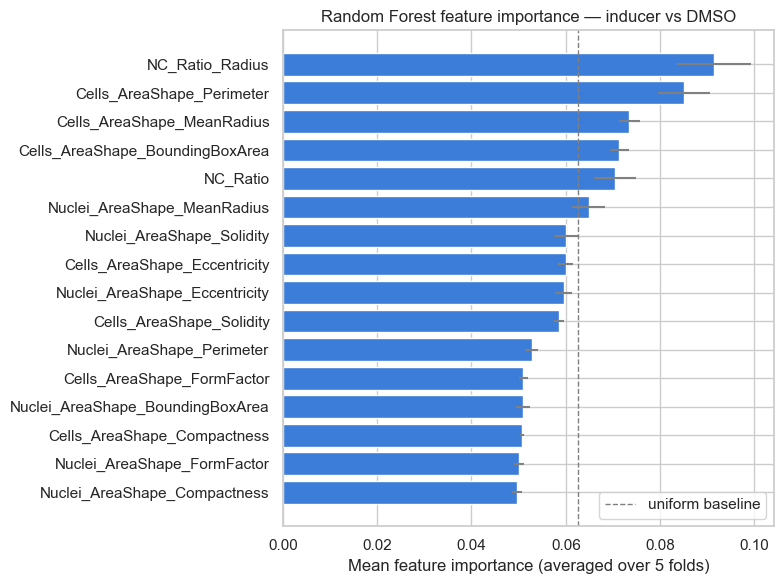

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df["feature"], importance_df["mean_importance"],
        xerr=importance_df["std_importance"], color="#3B7DD8", error_kw={"ecolor": "grey"})
ax.invert_yaxis()
ax.axvline(1 / len(FEATURES), color="grey", linestyle="--", linewidth=1, label="uniform baseline")
ax.set_xlabel("Mean feature importance (averaged over 5 folds)")
ax.set_title("Random Forest feature importance — inducer vs DMSO")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES / "rf_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Resveratrol — held-out exploration

Here try use the model we trained above to justify how it will judge Resveratrol.

If the model says >50% on average, resveratrol cells look like inducers (this is consistent with Emiliya's slide 11 noting it shares a replication-stress profile with hydroxyurea).
If the model says <50%, resveratrol looks more like DMSO.
If the distribution is bimodal, resveratrol may produce a mixed population.

This requires a further discussion

In [22]:
# Headline prediction — use the final model trained on ALL training data (from §8).
X_resv = df_holdout[FEATURES].values
resv_prob_final = final_clf.predict_proba(X_resv)[:, 1]

# Stability check — predict with each of the 5 fold models too.
fold_models = []   # NB: requires saving the per-fold models in §3
# (If §3 didn't save them, retrain quickly:)
for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
    m = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=42 + fold_idx, n_jobs=-1)
    m.fit(X[tr], y[tr])
    fold_models.append(m)

fold_probs = np.column_stack([m.predict_proba(X_resv)[:, 1] for m in fold_models])
# fold_probs shape: (n_resveratrol_cells, 5)
resv_prob_mean_across_folds = fold_probs.mean(axis=1)
resv_prob_std_across_folds  = fold_probs.std(axis=1)

print(f"Final-model probability — mean: {resv_prob_final.mean():.3f}")
print(f"Avg-of-folds probability — mean: {resv_prob_mean_across_folds.mean():.3f}")
print(f"Per-cell std across folds — mean: {resv_prob_std_across_folds.mean():.3f}  (lower = more stable)")


Final-model probability — mean: 0.200
Avg-of-folds probability — mean: 0.199
Per-cell std across folds — mean: 0.039  (lower = more stable)


## 7. Per-fold accuracy — sanity check for stability

If accuracy is wildly different across folds, the model isn't generalizing well. Stable accuracies across folds give us more confidence in the headline number.

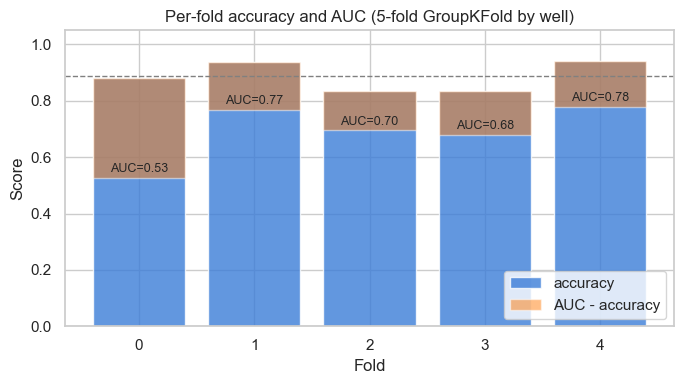

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df["fold"].astype(str), results_df["accuracy"], color="#3B7DD8", alpha=0.8, label="accuracy")
ax.bar(results_df["fold"].astype(str), results_df["auc"] - results_df["accuracy"],
       bottom=results_df["accuracy"], color="#FF7F0E", alpha=0.5, label="AUC - accuracy")
ax.axhline(results_df["accuracy"].mean(), color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_title("Per-fold accuracy and AUC (5-fold GroupKFold by well)")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
for i, (a, u) in enumerate(zip(results_df["accuracy"], results_df["auc"])):
    ax.text(i, u + 0.02, f"AUC={u:.2f}", ha="center", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES / "rf_per_fold.png", dpi=200, bbox_inches="tight")
plt.show()


Performance varies across wells, suggesting the model may not generalize equally well to all experimental wells.

## 8. Save the trained model

In [13]:
import joblib

final_clf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1,
)
final_clf.fit(X, y)
model_path = MODELS / "rf_inducer_vs_dmso.joblib"
joblib.dump({"model": final_clf, "features": FEATURES, "trained_on": "DMSO + 3 inducers"}, model_path)
print(f"Saved model to {model_path}")


Saved model to /Users/zhangyuxiang/Desktop/cell-aging-analysis/outputs/models/rf_inducer_vs_dmso.joblib
